In [ ]:
#Hypothesis 3: Properties that are ready for immediate or near-term purchase are more likely to be selected.

In [3]:
# import the data from a csv-file
import pandas as pd
df = pd.read_csv("data/eda.csv")

In [ ]:
df.isnull().sum()  # missing value

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
dtype: int64

In [5]:
df['sqft_living'].fillna(df['sqft_living'].median(), inplace=True)
df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)

C:\Users\manis\AppData\Local\Temp\ipykernel_22704\1798964272.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sqft_living'].fillna(df['sqft_living'].median(), inplace=True)
C:\Users\manis\AppData\Local\Temp\ipykernel_22704\1798964272.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [6]:
df['zipcode'].fillna(df['zipcode'].mode()[0], inplace=True)

C:\Users\manis\AppData\Local\Temp\ipykernel_22704\722458093.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['zipcode'].fillna(df['zipcode'].mode()[0], inplace=True)


In [7]:
df['date'].head()

0    2014-10-13
1    2014-12-09
2    2015-02-25
3    2014-12-09
4    2015-02-18
Name: date, dtype: object

In [ ]:
df['date'] = pd.to_datetime(df['date']) #convert day to daytime

In [9]:
df['date'].dtype

dtype('<M8[ns]')

In [ ]:
# count number of values
# Average price(mean)
# Standard deviation (spread)
df['price'].describe()

count    2.159700e+04
mean     5.402966e+05
std      3.673681e+05
min      7.800000e+04
25%      3.220000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [21]:
# Get latest date
latest_date = df['date'].max()

# Create 'recent' column (1 if within last 365 days, else 0)
df['recent'] = ((latest_date - df['date']).dt.days <= 365).astype(int)

# Create 'ready_score'
df['ready_score'] = df['recent'] * 2 + (df['yr_renovated'] > 0).astype(int)

# Print columns
print(df.columns)

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'recent',
       'ready_score'],
      dtype='object')


In [22]:
latest_date = df['date'].max()

In [23]:
df['recent'] = ((latest_date - df['date']).dt.days <= 365).astype(int)

In [24]:
ready_houses = df[df['recent'] == 1]

In [26]:
print(df.columns)

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'recent',
       'ready_score'],
      dtype='object')


In [27]:
q1 = df['price'].quantile(0.33)
q2 = df['price'].quantile(0.66)

def price_category(x):
    if x < q1:
        return 'low'
    elif x < q2:
        return 'mid'
    else:
        return 'high'

df['price_cat'] = df['price'].apply(price_category)

In [28]:
median_lat = df['lat'].median()

df['central'] = df['lat'] > median_lat

df['central'] = df['central'].astype(int)

In [29]:
nicole_houses = df[
    (df['recent'] == 1) &
    (df['price_cat'] == 'mid') &
    (df['central'] == 1)
]

In [30]:
nicole_houses.head()
len(nicole_houses)

3888

In [31]:
df['liveliness'] = df['view'] + df['grade'] + df['condition']

In [33]:
nicole_houses = df[
    (df['recent'] == 1) &
    (df['price_cat'] == 'mid') &
    (df['central'] == 1)
]

In [34]:
nicole_houses = nicole_houses.sort_values(
    by='liveliness', ascending=False
)

In [35]:
print(df.columns)

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'recent', 'ready_score',
       'price_cat', 'central', 'liveliness'],
      dtype='object')


In [36]:
nicole_houses.head(10)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,date,price,recent,ready_score,price_cat,central,liveliness
18777,6137610540,3.0,2.25,2550.0,8588.0,1.0,0.0,4.0,3,9,...,-122.195,3050.0,8588.0,2014-08-27,490000.0,1,2,mid,1,16.0
18348,8857320120,2.0,2.25,1800.0,2819.0,2.0,0.0,2.0,4,9,...,-122.113,1800.0,2755.0,2015-03-10,542000.0,1,2,mid,1,15.0
3946,1825069031,4.0,1.75,2410.0,8447.0,2.0,NaN,3.0,4,8,...,-122.088,2520.0,14789.0,2014-08-14,550000.0,1,3,mid,1,15.0
3947,1825069031,4.0,1.75,2410.0,8447.0,2.0,NaN,3.0,4,8,...,-122.088,2520.0,14789.0,2014-10-16,550000.0,1,3,mid,1,15.0
7050,8833510190,4.0,2.50,2650.0,9627.0,1.0,0.0,3.0,4,8,...,-122.254,2650.0,9221.0,2014-10-31,490000.0,1,2,mid,1,15.0
8495,7987401095,3.0,2.50,2380.0,2500.0,3.0,0.0,3.0,3,9,...,-122.375,2270.0,5000.0,2014-11-13,549950.0,1,2,mid,1,15.0
15485,3425079088,3.0,2.50,2210.0,70567.0,2.0,0.0,3.0,3,9,...,-121.895,2000.0,73616.0,2014-08-19,509950.0,1,2,mid,1,15.0
15500,1954630080,3.0,2.50,2840.0,48716.0,1.0,0.0,3.0,3,9,...,-121.915,2710.0,43676.0,2014-06-19,500000.0,1,2,mid,1,15.0
12728,6383000150,3.0,1.00,1630.0,6009.0,1.0,0.0,3.0,4,8,...,-122.383,2120.0,6009.0,2014-08-06,550000.0,1,2,mid,1,15.0
353,3363900111,2.0,1.00,990.0,3120.0,1.0,NaN,2.0,5,7,...,-122.353,1930.0,3120.0,2014-12-03,437500.0,1,2,mid,1,14.0


In [37]:
top5 = nicole_houses.head(5)[[
    'price', 'bedrooms', 'bathrooms',
    'sqft_living', 'zipcode',
    'view', 'grade', 'condition'
]]

top5

,price,bedrooms,bathrooms,sqft_living,zipcode,view,grade,condition
18777,490000.0,3.0,2.25,2550.0,98011,4.0,9,3
18348,542000.0,2.0,2.25,1800.0,98008,2.0,9,4
3946,550000.0,4.0,1.75,2410.0,98074,3.0,8,4
3947,550000.0,4.0,1.75,2410.0,98074,3.0,8,4
7050,490000.0,4.0,2.50,2650.0,98028,3.0,8,4


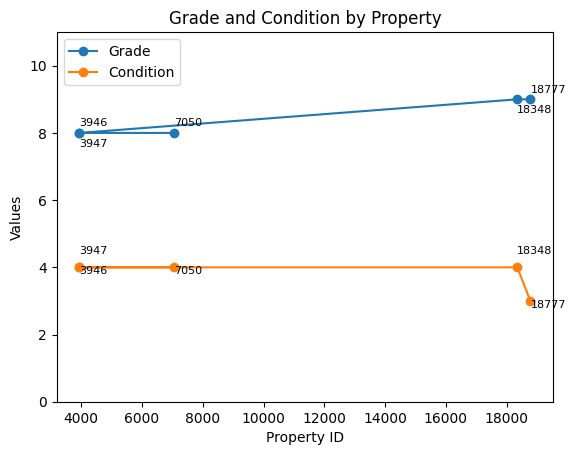

In [ ]:
import matplotlib.pyplot as plt

ids = [18777, 18348, 3946, 3947, 7050]
grade = [9, 9, 8, 8, 8]
condition = [3, 4, 4, 4, 4]

plt.figure()

plt.plot(ids, grade, marker='o', label='Grade')
plt.plot(ids, condition, marker='o', label='Condition')

#  Smart label placement
for i in range(len(ids)):
    offset = 0.2 if i % 2 == 0 else -0.4  # alternate up/down
    
    plt.text(ids[i], grade[i] + offset, str(ids[i]), fontsize=8)
    plt.text(ids[i], condition[i] - offset, str(ids[i]), fontsize=8)

plt.xlabel("Property ID")
plt.ylabel("Values")
plt.title("Grade and Condition by Property")

plt.ylim(0, max(grade) + 2)

plt.legend()
plt.show()

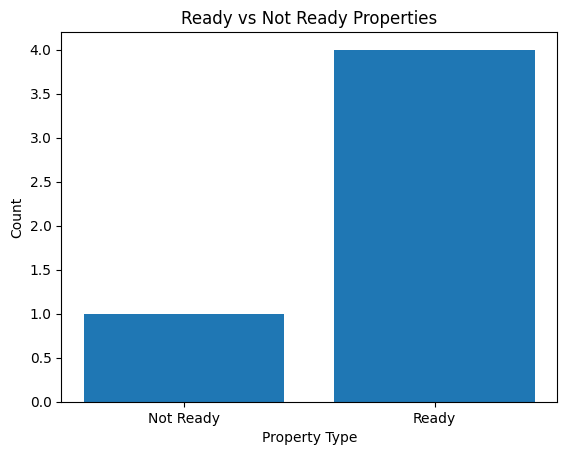

In [48]:
grade = [9, 9, 8, 8, 8]
condition = [3, 4, 4, 4, 4]

# Create readiness
ready = [1 if (c >= 4 and g >= 8) else 0 for c, g in zip(condition, grade)]

labels = ['Not Ready', 'Ready']
values = [ready.count(0), ready.count(1)]

plt.figure()
plt.bar(labels, values)

plt.xlabel("Property Type")
plt.ylabel("Count")
plt.title("Ready vs Not Ready Properties")

plt.show()